# Beta-Binomial Example

Let's assume we're running a marketing campaign where we have sent emails to 50 people and 20 of them have responded. We want to learn about the response rate to our emails.

The response to each email can be modeled as a Bernoulli distribution (a binomial distribution with one trial), where a success (y = 1) corresponds to a response and a failure (y = 0) corresponds to no response. The parameter θ of this distribution is the response rate, which is unknown and is the quantity we want to infer.

We'll use a **beta prior** on θ, reflecting our prior belief about the response rate before seeing the data. The beta distribution is a convenient choice because it is a **conjugate prior** for the binomial distribution.

> **Conjugate prior:** A prior is conjugate to a likelihood if the posterior belongs to the same distribution family as the prior. Here, Beta × Binomial → Beta posterior (exact closed-form update, no MCMC needed).

The core principle of Bayesian inference:

$$\text{posterior} \propto \text{likelihood} \times \text{prior}$$

- **Prior** — what we believe about θ before seeing data
- **Likelihood** — how probable the observed data is given θ
- **Posterior** — updated beliefs after combining prior and data

---

-   Let's define our prior distribution, and visualize it.

In [ ]:
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

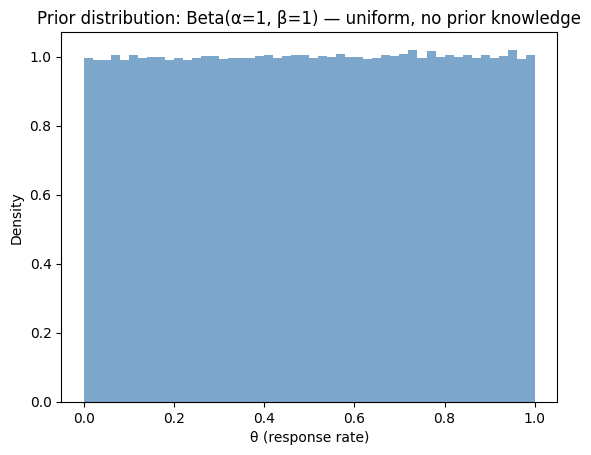

In [27]:
from scipy.stats import beta
from scipy.stats import binom
import matplotlib.pyplot as plt

# Prior hyperparameters
# Beta(1, 1) is a uniform distribution over [0, 1]:
# it assigns equal probability to every possible response rate.
# This represents maximum uncertainty — we have no prior knowledge.
alpha_prior = 1
beta_prior = 1

## Visualize the prior distribution
plt.clf()
plt.hist(beta.rvs(alpha_prior, beta_prior, size=1000000), bins=50, density=True, color='steelblue', alpha=0.7)
plt.xlabel("θ (response rate)")
plt.ylabel("Density")
plt.title(f"Prior distribution: Beta(α={alpha_prior}, β={beta_prior}) — uniform, no prior knowledge")
plt.show()

-   Here is a 95% **prior** credible interval for the parameter $\theta$.

In [32]:
# 95% prior credible interval for theta
# Since Beta(1,1) is uniform, the 95% CI spans almost the entire [0,1] range —
# this reflects that before seeing any data, we are nearly equally uncertain about all values of θ.
beta.ppf([0.025, 0.975], alpha_prior, beta_prior)

array([0.025, 0.975])

-   Let's use our data to update the parameters of the posterior distribution, and visualize the distribution in a histogram.

Posterior: Beta(α=21, β=31)
Posterior mean: 0.404


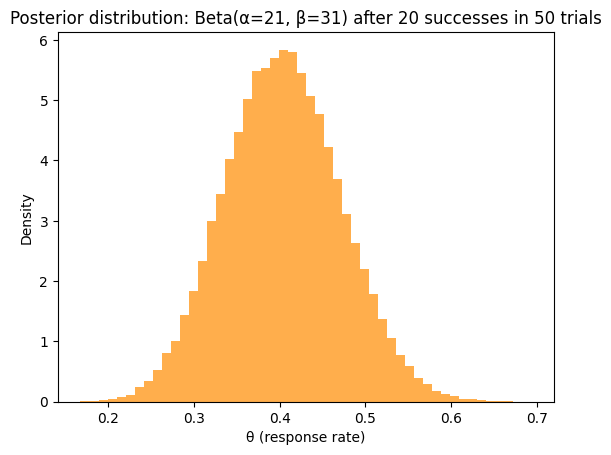

In [35]:
# Data
N = 50  # number of trials
x = 20  # number of successes

# Conjugate update rule:
#   Beta(α, β) prior + Binomial(N, θ) likelihood → Beta(α + x, β + N - x) posterior
# Intuition: each success "adds" to α (more evidence for high θ),
#            each failure "adds" to β (more evidence for low θ).
# This is the closed-form Bayesian update — no MCMC needed.
alpha_posterior = alpha_prior + x
beta_posterior = beta_prior + (N - x)

print(f"Posterior: Beta(α={alpha_posterior}, β={beta_posterior})")
print(f"Posterior mean: {alpha_posterior / (alpha_posterior + beta_posterior):.3f}")

plt.clf()
plt.hist(beta.rvs(alpha_posterior, beta_posterior, size=100000), bins=50, density=True, color='darkorange', alpha=0.7)
plt.xlabel("θ (response rate)")
plt.ylabel("Density")
plt.title(f"Posterior distribution: Beta(α={alpha_posterior}, β={beta_posterior}) after {x} successes in {N} trials")
plt.show()

-   Here is a 95% **posterior** credible interval for $\theta$.

In [36]:
# 95% posterior credible interval for theta
prior_ci = beta.ppf([0.025, 0.975], alpha_prior, beta_prior)
posterior_ci = beta.ppf([0.025, 0.975], alpha_posterior, beta_posterior)

print(f"Prior 95% CI:     [{prior_ci[0]:.3f}, {prior_ci[1]:.3f}]  (width: {prior_ci[1]-prior_ci[0]:.3f})")
print(f"Posterior 95% CI: [{posterior_ci[0]:.3f}, {posterior_ci[1]:.3f}]  (width: {posterior_ci[1]-posterior_ci[0]:.3f})")
print("→ The data significantly narrowed our uncertainty about θ.")

Prior 95% CI:     [0.025, 0.975]  (width: 0.950)
Posterior 95% CI: [0.276, 0.539]  (width: 0.263)
→ The data significantly narrowed our uncertainty about θ.


-   If we observe **50 new customers,** what is the **predictive distribution** that accounts both for the inherent variablility of the random sample of customers **and** the uncertainty related to the parameter $\theta$?

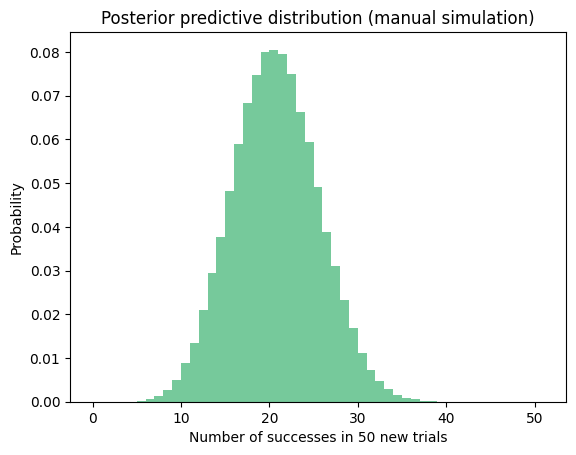

In [38]:
# Posterior predictive distribution — manual simulation (two-step composition)
#
# Step 1: Sample theta from the posterior — this captures our uncertainty about the true rate
# Step 2: Given each theta, sample y_new from Binomial(50, theta) — this captures random variability
# of new data even if we knew θ exactly
#
# Combining both steps yields the posterior predictive distribution,
# which is more spread out than a simple Binomial because theta itself is uncertain.

theta = beta.rvs(alpha_posterior, beta_posterior, size=100000)
future_obs = binom.rvs(50, theta, size=100000)

plt.clf()
plt.hist(future_obs, bins=range(0, 52), density=True, color='mediumseagreen', alpha=0.7)
plt.xlabel("Number of successes in 50 new trials")
plt.ylabel("Probability")
plt.title("Posterior predictive distribution (manual simulation)")
plt.show()

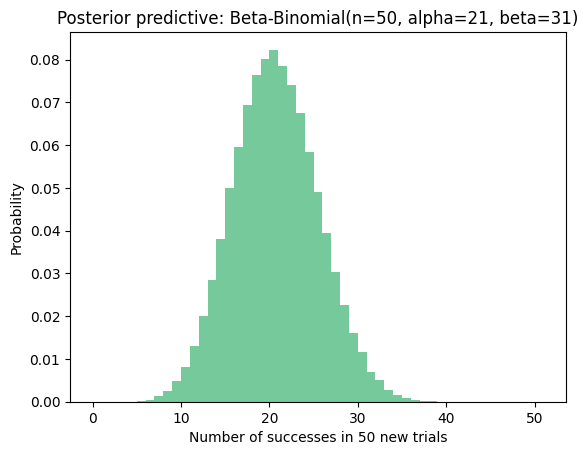

In [39]:
from scipy.stats import betabinom

# The Beta-Binomial is the analytical compound distribution that results from
# integrating out theta. It gives the same result as the manual simulation above,
# but as a closed-form distribution.
plt.clf()
plt.hist(betabinom.rvs(50, alpha_posterior, beta_posterior, size=100000),
         bins=range(0, 52), density=True, color='mediumseagreen', alpha=0.7)
plt.xlabel("Number of successes in 50 new trials")
plt.ylabel("Probability")
plt.title("Posterior predictive: Beta-Binomial(n=50, alpha=21, beta=31)")
plt.show()

-   Notice this is **not the same** as just picking from a binomial distribution - the compound beta-binomial distribution above has more variance.

    -   Look how many more observations are below 10 or above 30.

Posterior mean θ = 0.404
Binomial(50, 0.404) variance:  12.13
Beta-Binomial(50, 21, 31)  variance:  23.21
→ Beta-Binomial has higher variance because θ is uncertain, not fixed.


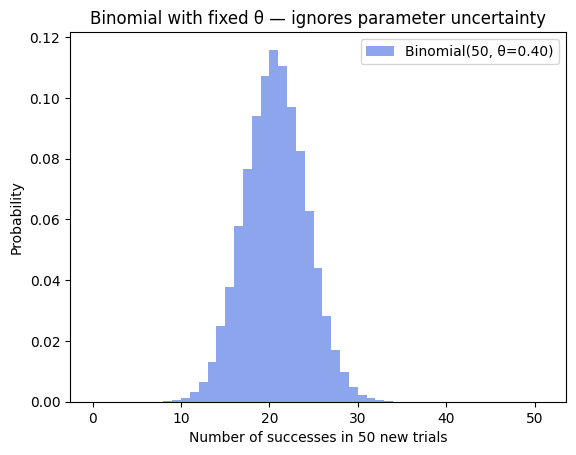

In [40]:
import numpy as np

# For comparison: a plain Binomial uses a fixed theta = posterior mean.
# It ignores the residual uncertainty about theta, so it underestimates variance.
posterior_mean = alpha_posterior / (alpha_posterior + beta_posterior)

binom_samples = binom.rvs(50, posterior_mean, size=100000)
bb_samples = betabinom.rvs(50, alpha_posterior, beta_posterior, size=100000)

print(f"Posterior mean θ = {posterior_mean:.3f}")
print(f"Binomial(50, {posterior_mean:.3f}) variance:  {np.var(binom_samples):.2f}")
print(f"Beta-Binomial(50, 21, 31)  variance:  {np.var(bb_samples):.2f}")
print("→ Beta-Binomial has higher variance because θ is uncertain, not fixed.")

plt.clf()
plt.hist(binom_samples, bins=range(0, 52), density=True, alpha=0.6, color='royalblue', label=f"Binomial(50, θ={posterior_mean:.2f})")
plt.xlabel("Number of successes in 50 new trials")
plt.ylabel("Probability")
plt.title("Binomial with fixed θ — ignores parameter uncertainty")
plt.legend()
plt.show()

## Stan

-   Stan is a probabilistic programming language designed for probabilistic computation and Bayesian inference.

-   It is not necessary to use Stan for these simpler models because we have closed-form solutions with conjugate priors.

-   Seeing how Stan is structured reinforces to us how the various model components we've learned about are used — the prior, the likelihood, hyperparameters, predictive distributions, etc.

### Stan model structure

Every Stan program is organized into named blocks:

| Block | Purpose |
|---|---|
| `data { }` | Declare observed inputs (constants passed in from Python) |
| `parameters { }` | Declare unknowns to infer (θ) — Stan samples these |
| `model { }` | Specify the prior and likelihood using `~` notation |
| `generated quantities { }` | Compute derived outputs (predictions, log-likelihood) after each draw |

The `~` symbol in Stan means "is distributed as" and automatically adds log-probability contributions to the model.

In [8]:
## Import necessary libraries
from cmdstanpy import CmdStanModel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mode

# Define Stan model
stan_code = """
data {
  int<lower=0> N; // number of trials
  int<lower=0> y; // number of successes
  real<lower=0> alpha; // prior hyperparameter
  real<lower=0> beta; // prior hyperparameter
}
parameters {
  real<lower=0, upper=1> theta; // probability of success
}
model {
  theta ~ beta(alpha, beta); // prior
  y ~ binomial(N, theta); // likelihood
}
generated quantities {
  int y_pred;
  y_pred = binomial_rng(N, theta); // posterior predictive distribution
}
"""

# Write model to a file
with open("model.stan", "w") as f:
    f.write(stan_code)

# Compile model
model = CmdStanModel(stan_file="model.stan")

18:12:13 - cmdstanpy - INFO - compiling stan file /Users/natallialantukh/Desktop/Canada/skills/beta_binomial_distr/model.stan to exe file /Users/natallialantukh/Desktop/Canada/skills/beta_binomial_distr/model
18:12:20 - cmdstanpy - INFO - compiled model executable: /Users/natallialantukh/Desktop/Canada/skills/beta_binomial_distr/model


In [ ]:
# Data
N = 50  # number of trials
y = 20  # number of successes

# Prior hyperparameters
alpha_prior = 1
beta_prior = 1

# Package data for Stan
stan_data = {"N": N, "y": y, "alpha": alpha_prior, "beta": beta_prior}

# Run MCMC sampling
# chains=4:           run 4 independent Markov chains to verify convergence
# iter_sampling=1000: collect 1000 posterior draws per chain (4000 total) after warmup
# Default warmup=1000 draws per chain are used to tune the sampler and are discarded
fit = model.sample(data=stan_data, iter_sampling=1000, chains=4)

In [ ]:
# Extract posterior samples as a DataFrame (all variables: theta, y_pred, plus chain/iter metadata)
posterior_samples_df = fit.draws_pd()

# Convergence diagnostics
# R-hat (potential scale reduction factor): should be ≈ 1.0 (< 1.01 is ideal)
# ESS (effective sample size): should be > 400 for reliable estimates
summary = fit.summary()
print("Convergence diagnostics:")
print(summary[['Mean', 'StdDev', 'R_hat']].loc[['theta']])
print()

# 95% credible interval
ci = np.quantile(posterior_samples_df['theta'], [0.025, 0.975])
print(f"Stan 95% credible interval for theta: ({ci[0]:.3f}, {ci[1]:.3f})")
print(f"Analytical 95% CI:                    ({posterior_ci[0]:.3f}, {posterior_ci[1]:.3f})")
print("→ Stan MCMC and the analytical conjugate solution agree closely.")

In [ ]:
from scipy.stats import mode

# MAP estimate: the mode — the single most probable value of θ
# Mean: the expected value — averages across all probability mass
# They differ when the posterior is skewed; for symmetric posteriors they are equal.
map_estimate = mode(posterior_samples_df['theta']).mode
expected_value = np.mean(posterior_samples_df['theta'])

print(f"MAP estimate (mode) for theta: {map_estimate:.3f}")
print(f"Expected value (mean) for theta: {expected_value:.3f}")
print(f"Analytical posterior mean: {alpha_posterior / (alpha_posterior + beta_posterior):.3f}")

In [ ]:
# Posterior predictive samples from Stan's generated quantities block
# These were sampled inside Stan: for each θ draw, Stan ran binomial_rng(N, θ)
y_pred_samples = posterior_samples_df['y_pred']

plt.clf()
plt.hist(y_pred_samples, bins=range(0, 52), density=True, color='mediumseagreen', alpha=0.7,
         label="Stan posterior predictive")
plt.xlabel("Number of successes in 50 new trials")
plt.ylabel("Probability")
plt.title("Posterior predictive distribution (from Stan)")
plt.legend()
plt.show()

print(f"Stan predictive mean: {y_pred_samples.mean():.2f}")
print(f"Stan predictive std:  {y_pred_samples.std():.2f}")

---

## Algorithm Summary: Bayesian Inference for the Beta-Binomial Model

### Step-by-step workflow

```
1. DEFINE PRIOR
   Choose Beta(α, β) to encode prior beliefs about θ ∈ [0, 1]
   • Beta(1, 1)  → uniform: no prior knowledge
   • α > β       → believe θ is likely high (more successes expected)
   • α < β       → believe θ is likely low
   • α + β       → "strength" of prior (larger = less influence from data)

2. COLLECT DATA
   Observe x successes in N trials

3. UPDATE  (Bayes' Rule via conjugacy — closed-form)
   posterior = Beta(α + x,  β + (N − x))
   • Each success increments α  (evidence for higher θ)
   • Each failure  increments β  (evidence for lower  θ)

4. SUMMARIZE POSTERIOR
   • Mean  = (α + x) / (α + x + β + N − x)
   • Mode  = (α + x − 1) / (α + x + β + N − x − 2)   [for α+x > 1, β+N−x > 1]
   • 95% CI: beta.ppf([0.025, 0.975], α_post, β_post)

5. PREDICT NEW DATA  (Posterior Predictive Distribution)
   Two equivalent methods:
   a) Simulation:  draw θ* ~ Beta(α_post, β_post), then y_new ~ Binomial(N_new, θ*)
   b) Analytical:  y_new ~ BetaBinomial(N_new, α_post, β_post)
   ⚠ More variance than plain Binomial because θ itself is uncertain

6. (OPTIONAL) MCMC VIA STAN
   Use when no conjugate prior exists (complex models, multiple parameters)
   • Write model: data / parameters / model / generated quantities blocks
   • Run multiple chains (≥ 4), check R̂ ≈ 1.0 for convergence
   • Extract draws_pd(), compute CIs and point estimates
```

### Key takeaways

| Concept | Key insight |
|---|---|
| Conjugate prior | Beta × Binomial → Beta; no MCMC needed |
| Credible interval | Direct probability statement: "θ is in [a, b] with 95% probability" |
| Posterior predictive | Accounts for *both* sampling variability *and* parameter uncertainty |
| Overdispersion | Beta-Binomial variance > Binomial variance; use it when θ is unknown |
| Stan | General-purpose; same structure scales to any probabilistic model |